In [1]:
import pandas as pd
import numpy as np
 

In [2]:
df_orig = pd.read_excel("D:\online_retail\data\online_retail_II.xlsx", sheet_name=None)
df = pd.concat(df_orig.values(), ignore_index=True)


<>:1: SyntaxWarning: invalid escape sequence '\o'
<>:1: SyntaxWarning: invalid escape sequence '\o'
C:\Users\bhavi\AppData\Local\Temp\ipykernel_9936\606610705.py:1: SyntaxWarning: invalid escape sequence '\o'
  df_orig = pd.read_excel("D:\online_retail\data\online_retail_II.xlsx", sheet_name=None)


In [4]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [7]:
df.isna().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [8]:
print("Missing Customer IDs:", df['Customer ID'].isna().sum())

df = df.dropna(subset=['Customer ID'])

print("Shape after removing missing Customer IDs:", df.shape)

Missing Customer IDs: 243007
Shape after removing missing Customer IDs: (824364, 8)


In [9]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Convert Customer ID to string
df['Customer ID'] = df['Customer ID'].astype(str)

# Optional: StockCode as string
df['StockCode'] = df['StockCode'].astype(str)

print(df.dtypes)


Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID            object
Country                object
dtype: object


In [10]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

df = df.drop_duplicates()

print("Shape after duplicate removal:", df.shape)

Duplicate rows: 26479
Shape after duplicate removal: (797885, 8)


In [11]:
print("Rows with non-positive prices:",
      (df['Price'] <= 0).sum())

df = df[df['Price'] > 0]

print("Shape after price cleaning:", df.shape)


Rows with non-positive prices: 70
Shape after price cleaning: (797815, 8)


In [12]:
#Cancellation invoice flag
df['IsCancelled'] = (
    df['Invoice'].astype(str)
      .str.startswith('C')
)

# Negative quantity flag
df['IsReturn'] = df['Quantity'] < 0

print(df[['Invoice', 'Quantity',
          'IsCancelled', 'IsReturn']].head())

  Invoice  Quantity  IsCancelled  IsReturn
0  489434        12        False     False
1  489434        12        False     False
2  489434        12        False     False
3  489434        48        False     False
4  489434        24        False     False


In [13]:
df['TransactionValue'] = (
    df['Quantity'] * df['Price']
)

print(df[['Quantity',
          'Price',
          'TransactionValue']].head())

   Quantity  Price  TransactionValue
0        12   6.95              83.4
1        12   6.75              81.0
2        12   6.75              81.0
3        48   2.10             100.8
4        24   1.25              30.0


In [14]:
# preprocessing.py
# Core preprocessing pipeline for
# UCI Online Retail II Dataset
# Complete preprocessing pipeline for UCI Online Retail II dataset.

import pandas as pd
import numpy as np


 # NON-PRODUCT / INTERNAL STOCK CODES
NON_PRODUCT_CODES = {"POST", "DOT", "BANK CHARGES", "AMAZONFEE", "MANUAL", "CRUK"}


 # MAIN PREPROCESSING FUNCTION
 
def preprocess_online_retail( file_path, verbose=True ): #accepting file path rn but will edit it later
    #Parameters: filepath, verbose: a bool weather to print the logs 
    #Returns: A single cleaned dataset

    #LOAD DATA 
    if verbose:
        print("\nLoading dataset...")

    df_orig = pd.read_excel(r"D:\online_retail\data\online_retail_II.xlsx", sheet_name=None)
    df = pd.concat(df_orig.values(), ignore_index=True)

    if verbose:
        print(f"Initial Shape: {df.shape}")


    # STANDARDIZE COLUMN NAMES 
    df.columns = (
        df.columns
          .str.strip()
          .str.replace(" ", "_")
    )


    # REMOVE MISSING CUSTOMER IDs
    missing_ids = df['Customer_ID'].isna().sum()

    if verbose:
        print(f"\nMissing Customer IDs: {missing_ids}")

    df = df.dropna(subset=['Customer_ID'])


    # FIX DATATYPES
    # Dates to datetime
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
    # Customer ID to int then string to avoid floats
    df['Customer_ID'] = (
        df['Customer_ID']
          .astype(int)
          .astype(str)
    )
    # StockCode to a normalised str
    df['StockCode'] = (
        df['StockCode']
          .astype(str)
          .str.strip()
          .str.upper()
    )
    # Country
    df['Country'] = (
        df['Country']
          .astype(str)
          .str.strip()
          .str.title()
    )


    # REMOVE EXACT DUPLICATES  
    duplicate_count = df.duplicated().sum()
    if verbose:
        print(f"\nDuplicate Rows: {duplicate_count}")
    df = df.drop_duplicates()

      
    # REMOVE IMPOSSIBLE PRICES
    invalid_price_count = ((df['Price'] <= 0).sum())

    if verbose:
        print(f"\nRows with Invalid Prices: ", f"{invalid_price_count}")
    df = df[df['Price'] > 0]

    
    # REMOVE NON-PRODUCT STOCK CODES
    non_product_count = (df['StockCode'].isin(NON_PRODUCT_CODES).sum())
    if verbose:
        print(f"\nNon-product rows: ", f"{non_product_count}")
    # NOTE: We DO NOT remove them yet.
    # We preserve them in master dataset.
    # Downstream tasks can filter them.


    # CREATE FLAGS
    # Cancellation invoices
    df['IsCancelled'] = (
        df['Invoice']
          .astype(str)
          .str.startswith('C'))
    # Returns / negative quantities
    df['IsReturn'] = (df['Quantity'] <= 0)
    # Non-product / operational transactions
    df['IsNonProduct'] = (df['StockCode'].isin(NON_PRODUCT_CODES))

    
    # CREATE TRANSACTION VALUE
    df['TransactionValue'] = (df['Quantity'] * df['Price'])


    # SORT CHRONOLOGICALLY
    df = df.sort_values(by=['Customer_ID', 'InvoiceDate'])

    # RESET INDEX
    df = df.reset_index(drop=True)


    # FINAL LOGGING
    if verbose:

        print("\n========== FINAL SUMMARY ==========")

        print(f"\nFinal Dataset Shape: {df.shape}")

        print(f"\nUnique Customers: ", f"{df['Customer_ID'].nunique()}")

        print(f"Unique Invoices: ", f"{df['Invoice'].nunique()}")

        print(f"Date Range: ", f"{df['InvoiceDate'].min()} ", f"to ", f"{df['InvoiceDate'].max()}")

        print(f"\nCancelled Transactions: ", f"{df['IsCancelled'].sum()}")

        print(f"Return Transactions: ", f"{df['IsReturn'].sum()}")
        
        print("\n===================================")

    return df


In [15]:
df = preprocess_online_retail("data\online_retail_II.xlsx",True)
df.info()



Loading dataset...


<>:1: SyntaxWarning: invalid escape sequence '\o'
<>:1: SyntaxWarning: invalid escape sequence '\o'
C:\Users\bhavi\AppData\Local\Temp\ipykernel_9936\634898076.py:1: SyntaxWarning: invalid escape sequence '\o'
  df = preprocess_online_retail("data\online_retail_II.xlsx",True)


Initial Shape: (1067371, 8)

Missing Customer IDs: 243007

Duplicate Rows: 26479

Rows with Invalid Prices:  70

Non-product rows:  2052

========== FINAL SUMMARY ==========

Final Dataset Shape: (797815, 12)

Unique Customers:  5939
Unique Invoices:  44870
Date Range:  2009-12-01 07:45:00  to  2011-12-09 12:50:00

Cancelled Transactions:  18390
Return Transactions:  18390

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 797815 entries, 0 to 797814
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Invoice           797815 non-null  object        
 1   StockCode         797815 non-null  object        
 2   Description       797815 non-null  object        
 3   Quantity          797815 non-null  int64         
 4   InvoiceDate       797815 non-null  datetime64[ns]
 5   Price             797815 non-null  float64       
 6   Customer_ID       797815 non-null  object        
 7   Country     

In [16]:
def analyze_customer_behavior(df, verbose=True):

    invoice_df = (
        df[(~df['IsCancelled']) & (~df['IsReturn']) & (~df['IsNonProduct'])]
        .groupby(['Customer_ID', 'Invoice'])
        .agg({
            'InvoiceDate': 'min',
            'TransactionValue': 'sum'
        })
        .reset_index()
    )

    invoice_df = invoice_df.sort_values(
        ['Customer_ID', 'InvoiceDate']
    )

    purchase_counts = (
        invoice_df.groupby('Customer_ID')['Invoice']
        .nunique()
    )

    repeat_rate = (purchase_counts > 1).mean()

    invoice_df['PrevInvoiceDate'] = (
        invoice_df.groupby('Customer_ID')['InvoiceDate']
        .shift(1)
    )

    invoice_df['GapDays'] = (
        invoice_df['InvoiceDate']
        - invoice_df['PrevInvoiceDate']
    ).dt.days

    gaps = invoice_df['GapDays'].dropna()

    gap_stats = gaps.describe()

    within_30 = (gaps <= 30).mean()
    within_60 = (gaps <= 60).mean()
    within_90 = (gaps <= 90).mean()
    within_75 = (gaps <= 75).mean()

    if verbose:

        print(f"Invoice-level shape: {invoice_df.shape}")

        print(f"Unique customers: {invoice_df['Customer_ID'].nunique()}")

        print(f"Repeat customer rate: {repeat_rate:.2%}")

        print(f"Median inter-purchase gap: {gaps.median():.2f} days")

        print(f"Mean inter-purchase gap: {gaps.mean():.2f} days")

        print(f"90th percentile gap: {gaps.quantile(0.9):.2f} days")

        print(f"Returned within 30 days: {within_30:.2%}")

        print(f"Returned within 60 days: {within_60:.2%}")

        print(f"Returned within 90 days: {within_90:.2%}")

        print(f"Returned within 75 days: {within_75:.2%}")

    return {
        'invoice_df': invoice_df,
        'gap_stats': gap_stats,
        'repeat_rate': repeat_rate,
        'within_30': within_30,
        'within_60': within_60,
        'within_90': within_90
    }

In [17]:
ana = analyze_customer_behavior(df)

Invoice-level shape: (36829, 6)
Unique customers: 5877
Repeat customer rate: 72.26%
Median inter-purchase gap: 24.00 days
Mean inter-purchase gap: 51.43 days
90th percentile gap: 135.00 days
Returned within 30 days: 55.86%
Returned within 60 days: 74.70%
Returned within 90 days: 83.26%
Returned within 75 days: 79.57%


In [18]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,IsCancelled,IsReturn,IsNonProduct,TransactionValue
0,491725,TEST001,This is a test product.,10,2009-12-14 08:34:00,4.5,12346,United Kingdom,False,False,False,45.0
1,491742,TEST001,This is a test product.,5,2009-12-14 11:00:00,4.5,12346,United Kingdom,False,False,False,22.5
2,491744,TEST001,This is a test product.,5,2009-12-14 11:02:00,4.5,12346,United Kingdom,False,False,False,22.5
3,492718,TEST001,This is a test product.,5,2009-12-18 10:47:00,4.5,12346,United Kingdom,False,False,False,22.5
4,492722,TEST002,This is a test product.,1,2009-12-18 10:55:00,1.0,12346,United Kingdom,False,False,False,1.0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 797815 entries, 0 to 797814
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Invoice           797815 non-null  object        
 1   StockCode         797815 non-null  object        
 2   Description       797815 non-null  object        
 3   Quantity          797815 non-null  int64         
 4   InvoiceDate       797815 non-null  datetime64[ns]
 5   Price             797815 non-null  float64       
 6   Customer_ID       797815 non-null  object        
 7   Country           797815 non-null  object        
 8   IsCancelled       797815 non-null  bool          
 9   IsReturn          797815 non-null  bool          
 10  IsNonProduct      797815 non-null  bool          
 11  TransactionValue  797815 non-null  float64       
dtypes: bool(3), datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 57.1+ MB


In [20]:
df['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

In [21]:
df['InvoiceDate'].min()


Timestamp('2009-12-01 07:45:00')

In [22]:
# classification_dataset.py

import pandas as pd
import numpy as np
 
# MAIN FUNCTION FOR BUILDING RETENTION CLASSIFICATION DATASET
 

def build_retention_dataset(df, cutoff_date='2011-09-09', prediction_days=90, active_days=180, verbose=True):

    # CONVERTING INPUT CUTOFF DATE INTO PANDAS TIMESTAMP
    # This becomes the boundary separating historical feature generation and Future retention label generation
    cutoff_date = pd.Timestamp(cutoff_date)

  
    # DEFINING FUTURE PREDICTION WINDOW END DATE
    # Customers purchasing between:
    # cutoff_date -> prediction_end
    # receive retention label = 1
    prediction_end = (cutoff_date + pd.Timedelta(days=prediction_days))

  
    # DEFINING RECENT ACTIVITY WINDOW
    # Customers inactive for too long before cutoff
    # are excluded to avoid trivial dead-user predictions
    active_start = (cutoff_date - pd.Timedelta(days=active_days))

  
    # FILTERING ONLY GENUINE PURCHASE TRANSACTIONS
    # Removing:
    # 1. Cancelled invoices
    # 2. Product returns
    # 3. Operational/non-product transactions
    purchase_df = df[
        (~df['IsCancelled']) &
        (~df['IsReturn']) &
        (~df['IsNonProduct'])].copy()

  
    # SORTING PURCHASES CHRONOLOGICALLY 
    # Sorting by customer then time is essential for:
    # 1. Gap calculations
    # 2. Recency features
    # 3. Temporal behavior modeling
    purchase_df = purchase_df.sort_values(['Customer_ID', 'InvoiceDate'])

  
    # SPLITTING HISTORICAL AND FUTURE DATA
    # Historical data:
    # Used ONLY for feature engineering
    history_df = purchase_df[purchase_df['InvoiceDate'] < cutoff_date].copy()
    # Future data:
    # Used ONLY for retention label creation
    future_df = purchase_df[
        (purchase_df['InvoiceDate'] >= cutoff_date) &
        (purchase_df['InvoiceDate'] < prediction_end)
    ].copy()

  
    # IDENTIFYING RECENTLY ACTIVE CUSTOMERS
    # Keeping only customers active within recent window
    # avoids learning from ancient dormant customers
    recent_active_customers = (
        history_df[
            history_df['InvoiceDate'] >= active_start
        ]['Customer_ID']
        .unique()
    )

  
    # FILTERING HISTORY TO ACTIVE CUSTOMERS ONLY
    # This ensures:
    # every customer had at least some recent activity
    history_df = history_df[history_df['Customer_ID'].isin(recent_active_customers)]

  
    # FILTERING FUTURE DATA TO SAME CUSTOMER SET
    # Future labels must only exist for valid customers
    future_df = future_df[future_df['Customer_ID'].isin(recent_active_customers)]

  
    # CREATING INVOICE-LEVEL AGGREGATION
    # Raw dataset is transaction-line level:
    # one row per purchased item

    # Here we aggregate into one row per invoice/order
    # This captures cleaner order-level behavior
    invoice_df = (
        history_df
        .groupby(['Customer_ID', 'Invoice'])
        .agg({
            # First timestamp of invoice
            'InvoiceDate': 'min',
            # Total spend within invoice
            'TransactionValue': 'sum',
            # Total quantity purchased in invoice
            'Quantity': 'sum',
            # Number of unique products in invoice
            'StockCode': 'nunique'
        })
        .reset_index()
    )

  
    # SORTING INVOICE-LEVEL DATA CHRONOLOGICALLY
    # Required for temporal customer calculations
    invoice_df = invoice_df.sort_values(['Customer_ID', 'InvoiceDate'])

  
    # CREATING CUSTOMER-LEVEL AGGREGATED FEATURES
    # Final dataset requires none row per customer
    # So invoice-level behavior is aggregated upward
    customer_features = (
        invoice_df
        .groupby('Customer_ID')
        .agg(
            # Most recent purchase timestamp
            LastPurchaseDate=('InvoiceDate', 'max'),
            # First ever purchase timestamp
            FirstPurchaseDate=('InvoiceDate', 'min'),
            # Total number of orders placed
            Frequency=('Invoice', 'nunique'),
            # Total customer spending
            Monetary=('TransactionValue', 'sum'),
            # Average spend per order
            AvgBasketValue=('TransactionValue', 'mean'),
            # Average quantity purchased per order
            AvgQuantity=('Quantity', 'mean'),
            # Total unique products purchased
            UniqueProducts=('StockCode', 'sum')
        )
        .reset_index()
    )

  
    # DERIVING RECENCY FEATURE
    # Measures: days since customer's last purchase
    # Lower recency usually means:
    # higher probability of returning
    customer_features['Recency'] = (cutoff_date - customer_features['LastPurchaseDate']).dt.days

  
    # DERIVING CUSTOMER LIFETIME FEATURE
    # Measures: duration between first and latest purchase
    # Helps distinguish new customers vs mature loyal customers
    customer_features['LifetimeDays'] = (customer_features['LastPurchaseDate'] - customer_features['FirstPurchaseDate']).dt.days

  
    # PREVENTING DIVISION BY ZERO
    # Customers with single-day activity
    # would otherwise create divide-by-zero errors
    customer_features['LifetimeDays'] = (customer_features['LifetimeDays'].replace(0, 1))

  
    # DERIVING PURCHASE VELOCITY FEATURE
    # Measures: average order frequency per lifetime day
    # Captures long-term customer engagement intensity
    customer_features['PurchaseRate'] = (customer_features['Frequency']/customer_features['LifetimeDays'])

  
    # CREATING PREVIOUS PURCHASE TIMESTAMPS
    # Previous invoice timestamps are needed
    # for inter-purchase gap calculations
    invoice_df['PrevInvoiceDate'] = (invoice_df.groupby('Customer_ID')['InvoiceDate'].shift(1))

  
    # CALCULATING INTER-PURCHASE GAPS
    # Measures: time gap between consecutive purchases
    # Highly informative behavioral feature
    invoice_df['GapDays'] = (invoice_df['InvoiceDate']-invoice_df['PrevInvoiceDate']).dt.days

  
    # DERIVING AVERAGE INTER-PURCHASE GAP
    # Customers with lower average gaps
    # often show stronger retention tendencies
    avg_gap = (
        invoice_df
        .groupby('Customer_ID')['GapDays']
        .mean()
        .reset_index()
        .rename(columns={
            'GapDays': 'AvgGapDays'
        })
    )

  
    # MERGING GAP FEATURES INTO MAIN DATASET
    customer_features = customer_features.merge(avg_gap, on='Customer_ID', how='left')

  
    # DEFINING RECENT 30-DAY ACTIVITY WINDOW
    # Recent activity often predicts
    # short-term retention strongly
    last_30_start = (cutoff_date - pd.Timedelta(days=30))

  
    # EXTRACTING RECENT CUSTOMER ACTIVITY
    # Captures customer momentum immediately
    # before prediction cutoff
    last_30_df = history_df[history_df['InvoiceDate'] >= last_30_start]

  
    # CREATING RECENT MOMENTUM FEATURES
    # These features capture:
    # recent engagement intensity
    recent_features = (
        last_30_df
        .groupby('Customer_ID')
        .agg(
            # Number of recent orders
            PurchasesLast30Days=('Invoice', 'nunique'),
            # Recent spending volume
            SpendLast30Days=('TransactionValue', 'sum')
        )
        .reset_index()
    )

  
    # MERGING RECENT MOMENTUM FEATURES
    customer_features = customer_features.merge(recent_features, on='Customer_ID', how='left')

  
    # FILLING MISSING RECENT ACTIVITY VALUES
    # Customers without recent purchases
    # should receive zeros instead of NaNs
    customer_features[['PurchasesLast30Days', 'SpendLast30Days']] = customer_features[['PurchasesLast30Days', 'SpendLast30Days']].fillna(0)

  
    # COLLECTING HISTORICAL RETURN/CANCELLATION DATA
    # Behavioral instability signals
    # may help predict retention
    cancellation_df = df[(df['InvoiceDate'] < cutoff_date)]

  
    # CREATING RETURN/CANCELLATION FEATURES
    cancellation_features = (
        cancellation_df
        .groupby('Customer_ID')
        .agg(
            # Total historical transaction count
            TotalTransactions=('Invoice', 'count'),
            # Number of cancelled transactions
            CancelledTransactions=('IsCancelled', 'sum'),
            # Number of returned transactions
            ReturnedTransactions=('IsReturn', 'sum')
        ).reset_index())

  
    # DERIVING CANCELLATION RATE
    # Measures: proportion of customer cancellations
    cancellation_features['CancellationRate'] = (cancellation_features['CancelledTransactions']/cancellation_features['TotalTransactions'])

  
    # DERIVING RETURN RATE
    # Measures: proportion of customer returns
    cancellation_features['ReturnRate'] = (cancellation_features['ReturnedTransactions']/cancellation_features['TotalTransactions'])

  
    # MERGING CANCELLATION FEATURES
    customer_features = customer_features.merge(cancellation_features[
            [
                'Customer_ID',
                'CancellationRate',
                'ReturnRate'
            ]
        ],
        on='Customer_ID',
        how='left')

  
    # IDENTIFYING FUTURE RETURNING CUSTOMERS
    # Customers purchasing during future window
    # become positive retention examples
    future_labels = (
        future_df
        .groupby('Customer_ID')['Invoice']
        .nunique()
        .reset_index()
    )

  
    # ASSIGNING POSITIVE RETENTION LABELS
    future_labels['RetentionLabel'] = 1

  
    # MERGING LABELS INTO FINAL FEATURE TABLE
    customer_features = customer_features.merge(
        future_labels[
            ['Customer_ID', 'RetentionLabel']
        ],
        on='Customer_ID',
        how='left'
    )

  
    # ASSIGNING NEGATIVE LABELS TO NON-RETURNERS
    # Customers absent in future purchases
    # are labeled as non-retained
    customer_features['RetentionLabel'] = (
        customer_features['RetentionLabel']
        .fillna(0)
        .astype(int)
    )

  
    # REMOVING RAW TIMESTAMP COLUMNS
    # Derived features already contain needed information
    customer_features = customer_features.drop(columns=['LastPurchaseDate','FirstPurchaseDate'])

  
    # PRINTING FINAL DATASET STATISTICS
    if verbose:

        print(f"Cutoff date: {cutoff_date.date()}")

        print(f"Prediction end: {prediction_end.date()}")

        print(f"Active customer window: {active_days} days")

        print(f"Final dataset shape: {customer_features.shape}")

        print(f"Customers retained: ", f"{customer_features['RetentionLabel'].mean():.2%}")

        print(f"Positive labels: ", f"{customer_features['RetentionLabel'].sum()}")

        print(f"Negative labels: ", f"{(customer_features['RetentionLabel'] == 0).sum()}")

    return customer_features


In [23]:
retention_df = build_retention_dataset(
        df,
        cutoff_date='2011-09-09',
        prediction_days=90,
        active_days=180,
        verbose=True
    )

Cutoff date: 2011-09-09
Prediction end: 2011-12-08
Active customer window: 180 days
Final dataset shape: (2778, 15)
Customers retained:  61.45%
Positive labels:  1707
Negative labels:  1071


In [24]:
retention_df.head()

,Customer_ID,Frequency,Monetary,AvgBasketValue,AvgQuantity,UniqueProducts,Recency,LifetimeDays,PurchaseRate,AvgGapDays,PurchasesLast30Days,SpendLast30Days,CancellationRate,ReturnRate,RetentionLabel
0,12347,6,3402.39,567.065000,349.833333,164,37,274,0.021898,54.4,0.0,0.0,0.000000,0.000000,1
1,12348,4,1388.40,347.100000,622.000000,40,156,189,0.021164,63.0,0.0,0.0,0.000000,0.000000,1
2,12352,7,1825.61,260.801429,62.857143,52,170,130,0.053846,21.5,0.0,0.0,0.151515,0.151515,1
3,12353,2,406.76,203.380000,106.000000,24,112,204,0.009804,204.0,0.0,0.0,0.000000,0.000000,0
4,12354,1,1079.40,1079.400000,530.000000,58,140,1,1.000000,NaN,0.0,0.0,0.000000,0.000000,0


In [25]:
retention_df.isna().sum()

Customer_ID              0
Frequency                0
Monetary                 0
AvgBasketValue           0
AvgQuantity              0
UniqueProducts           0
Recency                  0
LifetimeDays             0
PurchaseRate             0
AvgGapDays             393
PurchasesLast30Days      0
SpendLast30Days          0
CancellationRate         0
ReturnRate               0
RetentionLabel           0
dtype: int64

In [26]:
retention_df.describe()

,Frequency,Monetary,AvgBasketValue,AvgQuantity,UniqueProducts,Recency,LifetimeDays,PurchaseRate,AvgGapDays,PurchasesLast30Days,SpendLast30Days,CancellationRate,ReturnRate,RetentionLabel
count,2778.000000,2778.000000,2778.000000,2778.000000,2778.000000,2778.000000,2778.000000,2778.000000,2385.000000,2778.000000,2778.000000,2778.000000,2778.000000,2778.000000
mean,8.552556,4114.153446,390.328561,238.229856,173.963283,65.051116,337.581713,0.181019,90.548441,0.476242,225.863247,0.025270,0.025270,0.614471
std,14.639871,16433.334077,539.056194,380.385311,365.083968,51.403691,218.839638,0.376934,83.959418,0.939842,1068.208909,0.051574,0.051574,0.486808
min,1.000000,2.900000,2.900000,1.000000,1.000000,0.000000,1.000000,0.003165,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,586.532500,194.932917,101.638249,33.000000,20.000000,123.000000,0.012870,38.687500,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5.000000,1464.725000,301.698000,170.888889,84.000000,52.000000,387.500000,0.021613,66.125000,0.000000,0.000000,0.004878,0.004878,1.000000
75%,10.000000,3494.707500,435.649063,276.500000,199.000000,104.000000,528.000000,0.047968,114.000000,1.000000,212.470000,0.030512,0.030512,1.000000
max,308.000000,456780.490000,14844.766667,12669.142857,8982.000000,179.000000,646.000000,3.000000,632.000000,16.000000,29775.780000,0.666667,0.666667,1.000000


In [60]:


from sklearn.model_selection import (train_test_split, RandomizedSearchCV)

# Preprocessing utilities
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler


# Missing value handling
from sklearn.impute import SimpleImputer

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# XGBoost classifier
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)



# HANDLING AvgGapDays MISSING VALUES
# Customers with one purchase have no gap history
retention_df['AvgGapDays'] = (retention_df['AvgGapDays'].fillna(999))

# SPLITTING FEATURES AND TARGET
# Input features
X = retention_df.drop(columns=['Customer_ID', 'RetentionLabel'])

# Target labels
y = retention_df['RetentionLabel']


# TRAIN TEST SPLIT
# Stratify preserves class distribution balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# FEATURES NEEDING LOG TRANSFORMATION  
# Highly right-skewed behavioral features
log_features = ['Frequency','Monetary','AvgBasketValue','SpendLast30Days','UniqueProducts']

# FEATURES NEEDING NORMAL SCALING ONLY   
scale_features = ['AvgQuantity','Recency','LifetimeDays','PurchaseRate','AvgGapDays','PurchasesLast30Days','CancellationRate','ReturnRate']


# PIPELINE FOR LOG-TRANSFORMED FEATURES   
log_pipeline = Pipeline([
    # Filling missing values
    ('imputer', SimpleImputer(strategy='median')),
    # Applying log(1+x)
    ('log_transform', FunctionTransformer(np.log1p)),
    # Standardizing transformed values
    ('scaler', StandardScaler())])

# PIPELINE FOR STANDARD-SCALED FEATURES   
scale_pipeline = Pipeline([
    # Filling missing values
    ('imputer', SimpleImputer(strategy='median')),
    # Standard scaling
    ('scaler', StandardScaler())])


# COMBINING PREPROCESSING PIPELINES   
preprocessor = ColumnTransformer([
    ('log', log_pipeline, log_features),
    ('scale', scale_pipeline, scale_features)])


# DEFINING MODELS   
models = {'LogisticRegression': LogisticRegression(),'KNN': KNeighborsClassifier(),'DecisionTree': DecisionTreeClassifier(),    
    'SVC': SVC(probability=True), 'RandomForest': RandomForestClassifier(),'XGBoost': XGBClassifier(eval_metric='logloss')}

   
# DEFINING RANDOM SEARCH PARAMETER GRIDS   
param_grids = {
    'LogisticRegression': {'model__C': [0.01, 0.1, 1, 10], 'model__penalty': ['l2']},
    'KNN': {'model__n_neighbors': [3, 5, 7, 11], 'model__weights': ['uniform', 'distance']},
    'DecisionTree': {'model__max_depth': [3, 5, 10, 20], 'model__min_samples_split': [2, 5, 10]},
    'SVC': {'model__C': [0.1, 1, 10], 'model__kernel': ['rbf', 'linear']},
    'RandomForest': {'model__n_estimators': [100, 200, 500], 'model__max_depth': [5, 10, 20], 'model__min_samples_split': [2, 5]},
    'XGBoost': {'model__n_estimators': [100, 200, 500], 'model__max_depth': [3, 5, 7], 'model__learning_rate': [0.01, 0.05, 0.1], 'model__subsample': [0.8, 1.0]}
}

   
# STORING MODEL RESULTS   
results = []
trained_models = {}

# TRAINING AND EVALUATING MODELS   
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    
    # CREATING COMPLETE MODEL PIPELINE
    pipeline = Pipeline([('preprocessing', preprocessor), ('model', model)])
    
    # RANDOMIZED HYPERPARAMETER SEARCH
    random_search = RandomizedSearchCV(estimator=pipeline, param_distributions=param_grids[model_name],
        n_iter=10, cv=5, scoring='f1', random_state=42, n_jobs=1 if model_name=='XGBClassifier' else -1)

    # TRAINING MODEL
    random_search.fit(X_train, y_train)

    # BEST MODEL AFTER SEARCH
    best_model = random_search.best_estimator_

    trained_models[model_name] = best_model

    # PREDICTING TEST LABELS
    y_pred = best_model.predict(X_test)

    # PREDICTING CLASS PROBABILITIES
    y_prob = best_model.predict_proba(X_test)[:, 1]

    # CALCULATING EVALUATION METRICS
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob)

       # PRINTING MODEL PERFORMANCE
   
    print(f"Best Params: {random_search.best_params_}")

    print(f"Accuracy: {accuracy:.4f}")

    print(f"Precision: {precision:.4f}")

    print(f"Recall: {recall:.4f}")

    print(f"F1 Score: {f1:.4f}")

    print(f"ROC AUC: {roc_auc:.4f}")

    # STORING RESULTS
   
    results.append({'Model': model_name, 'Accuracy': accuracy, 'Precision': precision,
        'Recall': recall, 'F1 Score': f1, 'ROC AUC': roc_auc})

   # FINAL MODEL COMPARISON TABLE
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by='ROC AUC', ascending=False)


# PRINTING FINAL RESULTS   
print("\nFinal Model Comparison:\n")
print(results_df)


Training LogisticRegression...


e:\Python\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Params: {'model__penalty': 'l2', 'model__C': 0.01}
Accuracy: 0.6745
Precision: 0.7069
Recall: 0.8041
F1 Score: 0.7524
ROC AUC: 0.7579

Training KNN...


e:\Python\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Params: {'model__weights': 'uniform', 'model__n_neighbors': 11}
Accuracy: 0.6871
Precision: 0.7211
Recall: 0.8012
F1 Score: 0.7590
ROC AUC: 0.7395

Training DecisionTree...
Best Params: {'model__min_samples_split': 5, 'model__max_depth': 5}
Accuracy: 0.6853
Precision: 0.7326
Recall: 0.7690
F1 Score: 0.7504
ROC AUC: 0.7345

Training SVC...


e:\Python\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Params: {'model__kernel': 'rbf', 'model__C': 1}
Accuracy: 0.6924
Precision: 0.7101
Recall: 0.8450
F1 Score: 0.7717
ROC AUC: 0.7442

Training RandomForest...
Best Params: {'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__max_depth': 5}
Accuracy: 0.6906
Precision: 0.7285
Recall: 0.7924
F1 Score: 0.7591
ROC AUC: 0.7666

Training XGBoost...
Best Params: {'model__subsample': 1.0, 'model__n_estimators': 200, 'model__max_depth': 3, 'model__learning_rate': 0.01}
Accuracy: 0.6906
Precision: 0.7179
Recall: 0.8187
F1 Score: 0.7650
ROC AUC: 0.7609

Final Model Comparison:

                Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
4        RandomForest  0.690647   0.728495  0.792398  0.759104  0.766642
5             XGBoost  0.690647   0.717949  0.818713  0.765027  0.760890
0  LogisticRegression  0.674460   0.706941  0.804094  0.752394  0.757856
3                 SVC  0.692446   0.710074  0.845029  0.771696  0.744220
1                 KNN  0.687050   0.721053  

In [28]:
# clustering_pipeline.py
import pandas as pd
import numpy as np

from sklearn.preprocessing import (
    StandardScaler,
    FunctionTransformer
)

from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Clustering algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
# Gaussian Mixture clustering
from sklearn.mixture import GaussianMixture

# Dimensionality reduction
from sklearn.decomposition import PCA

# Clustering evaluation metrics
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# Dataset generation pipeline
from classf_dataset import (
    build_retention_dataset
)

# Master preprocessing pipeline
from preprocessing import (
    preprocess_online_retail
)


# HANDLING MISSING GAP VALUES
# Customers with single purchases have no gap history
retention_df['AvgGapDays'] = (
    retention_df['AvgGapDays']
    .fillna(999)
)

  
# SELECTING FEATURES FOR CLUSTERING
# Keeping only behavioral segmentation features
cluster_features = ['Recency','Frequency','Monetary','AvgBasketValue','PurchaseRate','AvgGapDays','SpendLast30Days']
  
# CREATING CLUSTERING FEATURE MATRIX
X = retention_df[cluster_features].copy()

# FEATURES NEEDING LOG TRANSFORMATION: Highly skewed behavioral features
log_features = ['Frequency','Monetary','AvgBasketValue','SpendLast30Days']

# FEATURES NEEDING STANDARD SCALING
scale_features = ['Recency','PurchaseRate','AvgGapDays']

  
# PIPELINE FOR LOG-TRANSFORMED FEATURES
log_pipeline = Pipeline([
    # Filling missing values
    ('imputer', SimpleImputer(strategy='median')),
    # Applying log(1+x) transformation
    ('log_transform', FunctionTransformer(np.log1p)),
    # Standardizing transformed values
    ('scaler', StandardScaler())])
  
# PIPELINE FOR NORMAL FEATURES
scale_pipeline = Pipeline([
    # Filling missing values
    ('imputer', SimpleImputer(strategy='median')),
    # Standard scaling
    ('scaler', StandardScaler())])

  
# COMBINING PREPROCESSING PIPELINES
preprocessor = ColumnTransformer([
    ('log', log_pipeline, log_features),
    ('scale', scale_pipeline, scale_features)
])

# PREPROCESSING CLUSTERING FEATURES
X_processed = preprocessor.fit_transform(X)

# PCA DIMENSIONALITY REDUCTION
# Reducing dimensions for visualization and noise reduction
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

  
# DEFINING CLUSTERING MODELS
clustering_models = {'KMeans': KMeans(n_clusters=4, random_state=42),
                     'Agglomerative': AgglomerativeClustering(n_clusters=4),
                     'DBSCAN': DBSCAN(eps=1.2,min_samples=10),
                     'GaussianMixture': GaussianMixture(n_components=4,random_state=42)}


# STORING CLUSTERING RESULTS
results = []

# TRAINING AND EVALUATING CLUSTERING MODELS
for model_name, model in clustering_models.items():
    print(f"\nRunning {model_name}...")

    # FITTING CLUSTERING MODEL
    if model_name == 'GaussianMixture':
        # Gaussian mixture uses fit_predict separately
        cluster_labels = model.fit_predict(X_processed)

    else:
        # Standard clustering prediction
        cluster_labels = model.fit_predict(X_processed)

    # COUNTING UNIQUE CLUSTERS
    n_clusters = len(set(cluster_labels))

    # HANDLING DBSCAN NOISE LABELS
    # DBSCAN may create noise points labeled -1
    if -1 in cluster_labels:
        valid_mask = cluster_labels != -1
        X_eval = X_processed[valid_mask]
        labels_eval = cluster_labels[valid_mask]
    else:
        X_eval = X_processed
        labels_eval = cluster_labels

    # COMPUTING CLUSTERING METRICS
    silhouette = silhouette_score(
        X_eval,
        labels_eval
    )
    davies = davies_bouldin_score(
        X_eval,
        labels_eval
    )
    calinski = calinski_harabasz_score(
        X_eval,
        labels_eval
    )

    # PRINTING CLUSTERING PERFORMANCE
    print(f"Clusters found: {n_clusters}")
    print(f"Silhouette Score: {silhouette:.4f}")
    print(f"Davies Bouldin Score: {davies:.4f}")
    print(f"Calinski Harabasz Score: {calinski:.4f}")

    # STORING RESULTS
    results.append({
        'Model': model_name,
        'Clusters': n_clusters,
        'Silhouette Score': silhouette,
        'Davies Bouldin Score': davies,
        'Calinski Harabasz Score': calinski})

    # SAVING CLUSTER LABELS
    retention_df[f'{model_name}_Cluster'] = (cluster_labels)
 
# FINAL CLUSTERING RESULTS TABLE
results_df = pd.DataFrame(results)

# PRINTING FINAL MODEL COMPARISON
print("\nFinal Clustering Comparison:\n")
print(results_df)

  
# DISPLAYING CLUSTER DISTRIBUTIONS
for model_name in clustering_models.keys():
    print(f"\n{model_name} Cluster Counts:\n")
    print(
        retention_df[
            f'{model_name}_Cluster'
        ].value_counts()
    )

# DISPLAYING SAMPLE CLUSTERED DATA
print("\nClustered Dataset Sample:\n")
print(
    retention_df[
        [
            'Customer_ID',
            'KMeans_Cluster',
            'Agglomerative_Cluster',
            'DBSCAN_Cluster',
            'GaussianMixture_Cluster'
        ]
    ].head()
)


Running KMeans...
Clusters found: 4
Silhouette Score: 0.3244
Davies Bouldin Score: 1.1163
Calinski Harabasz Score: 1597.6868

Running Agglomerative...
Clusters found: 4
Silhouette Score: 0.3204
Davies Bouldin Score: 1.1298
Calinski Harabasz Score: 1523.8528

Running DBSCAN...
Clusters found: 4
Silhouette Score: 0.4409
Davies Bouldin Score: 0.8368
Calinski Harabasz Score: 885.6509

Running GaussianMixture...
Clusters found: 4
Silhouette Score: 0.2747
Davies Bouldin Score: 1.4684
Calinski Harabasz Score: 1289.0323

Final Clustering Comparison:

             Model  Clusters  Silhouette Score  Davies Bouldin Score  \
0           KMeans         4          0.324352              1.116261   
1    Agglomerative         4          0.320448              1.129797   
2           DBSCAN         4          0.440945              0.836830   
3  GaussianMixture         4          0.274725              1.468381   

   Calinski Harabasz Score  
0              1597.686826  
1              1523.852820  
2 

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

PRIMARY = "#2D3748"
SECONDARY = "#744210"
ACCENT = "#3182CE"
GRID = "#E2E8F0"
ROW_LIGHT = "#FFFBEB"

sns.set_style("whitegrid")

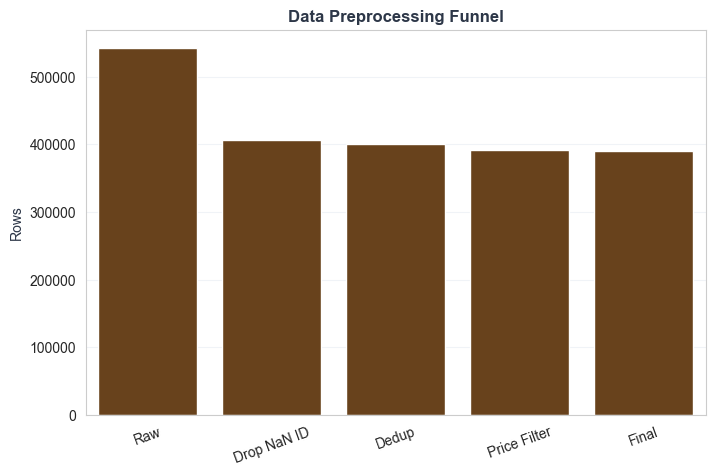

In [37]:
stages = ["Raw", "Drop NaN ID", "Dedup", "Price Filter", "Final"]
values = [541909, 406829, 401000, 392000, 390000]

plt.figure(figsize=(8,5))
sns.barplot(x=stages, y=values, color=SECONDARY)

plt.title("Data Preprocessing Funnel", color=PRIMARY, fontweight="bold")
plt.ylabel("Rows", color=PRIMARY)
plt.xticks(rotation=20)
plt.grid(axis="y", color=GRID, alpha=0.5)
plt.show()

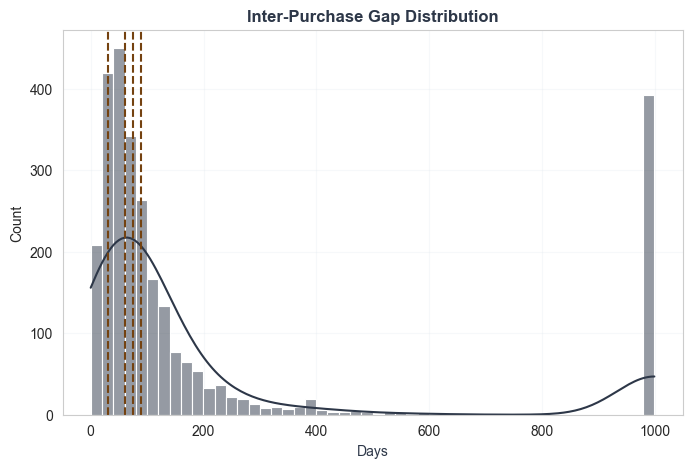

In [40]:
# replace gap_series with your df["AvgGapDays"]
gap_series = retention_df["AvgGapDays"]

plt.figure(figsize=(8,5))

sns.histplot(gap_series, bins=50, kde=True, color=PRIMARY)

for x in [30, 60, 75, 90]:
    plt.axvline(x, linestyle="--", color=SECONDARY)

plt.title("Inter-Purchase Gap Distribution", color=PRIMARY, fontweight="bold")
plt.xlabel("Days", color=PRIMARY)
plt.grid(alpha=0.3, color=GRID)

plt.show()

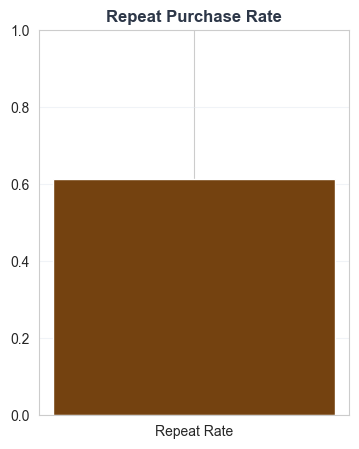

In [41]:
repeat_rate = 0.614

plt.figure(figsize=(4,5))
plt.bar(["Repeat Rate"], [repeat_rate], color=SECONDARY)

plt.ylim(0,1)
plt.title("Repeat Purchase Rate", color=PRIMARY, fontweight="bold")
plt.grid(axis="y", color=GRID, alpha=0.5)

plt.show()

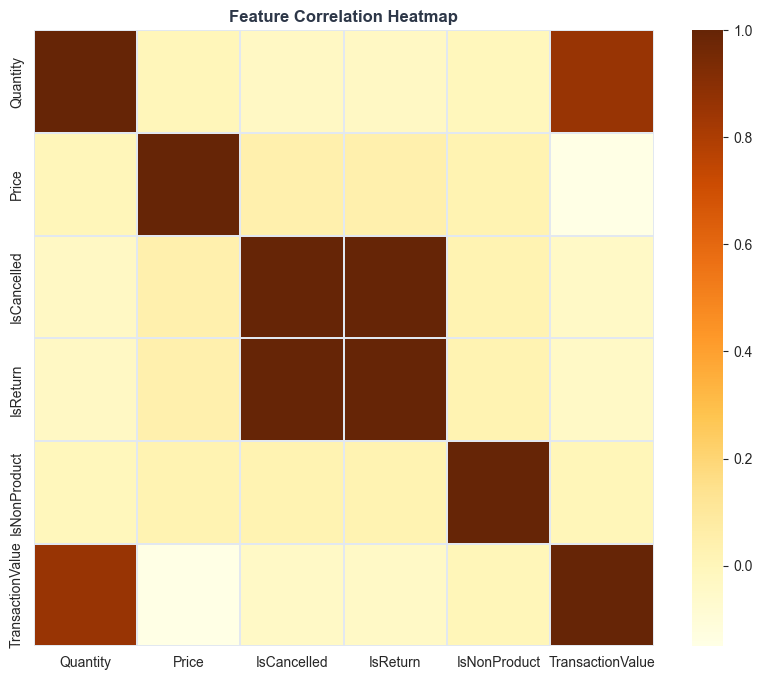

In [42]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="YlOrBr",
    linewidths=0.3,
    linecolor=GRID
)

plt.title("Feature Correlation Heatmap", color=PRIMARY, fontweight="bold")
plt.show()

In [48]:
print(results_df.columns)

Index(['Model', 'Clusters', 'Silhouette Score', 'Davies Bouldin Score',
       'Calinski Harabasz Score'],
      dtype='object')


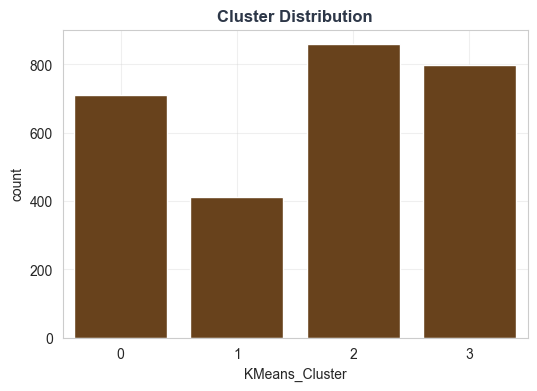

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(
    x="KMeans_Cluster",
    data=retention_df,
    color="#744210"
)

plt.title("Cluster Distribution", color="#2D3748", fontweight="bold")
plt.grid(alpha=0.3)

plt.show()

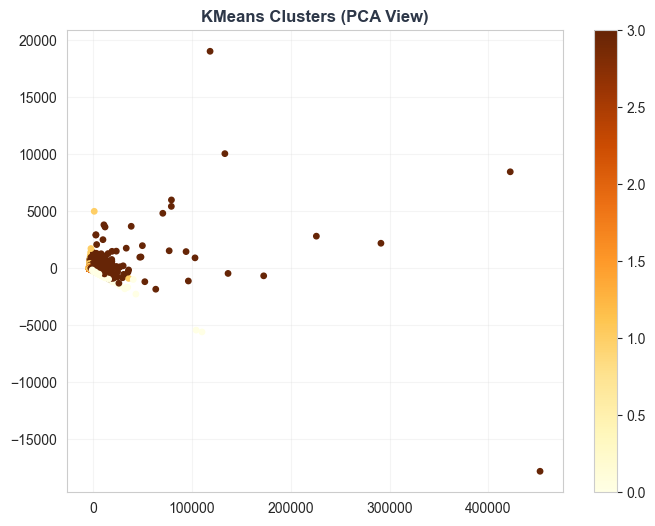

In [53]:
from sklearn.decomposition import PCA

cluster_features = ['Recency','Frequency','Monetary','AvgBasketValue','PurchaseRate','AvgGapDays','SpendLast30Days']

X = retention_df[cluster_features]

X_pca = PCA(n_components=2).fit_transform(X)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=retention_df["KMeans_Cluster"],
    cmap="YlOrBr",
    s=15
)

plt.title("KMeans Clusters (PCA View)", color="#2D3748", fontweight="bold")
plt.colorbar()
plt.grid(alpha=0.2)

plt.show()

C:\Users\bhavi\AppData\Local\Temp\ipykernel_9936\1037881318.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


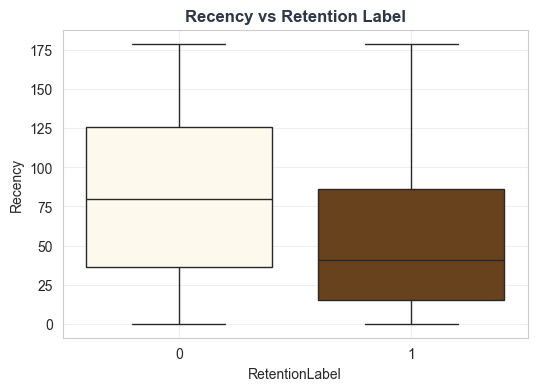

C:\Users\bhavi\AppData\Local\Temp\ipykernel_9936\1037881318.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


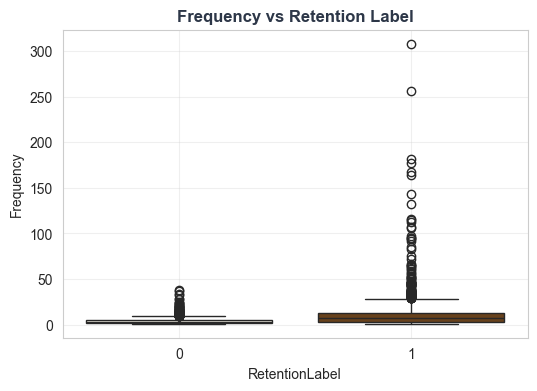

C:\Users\bhavi\AppData\Local\Temp\ipykernel_9936\1037881318.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


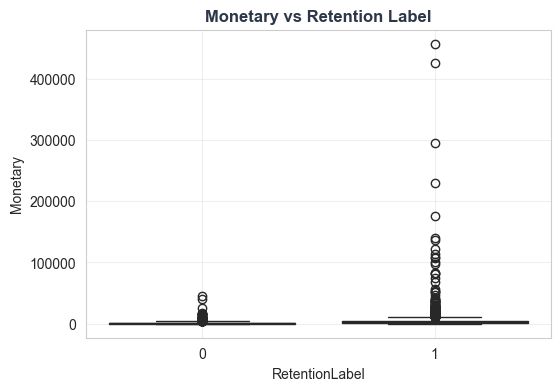

In [70]:
features = ["Recency", "Frequency", "Monetary"]

for col in features:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        x="RetentionLabel",
        y=col,
        data=retention_df,
        palette=["#FFFBEB", "#744210"]
    )

    plt.title(f"{col} vs Retention Label", color="#2D3748", fontweight="bold")
    plt.grid(alpha=0.3)

    plt.show()

In [63]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for name, model in trained_models.items():

    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test)[:,1]

    elif hasattr(model, "decision_function"):
        probs = model.decision_function(X_test)

        probs = (probs - probs.min()) / (probs.max() - probs.min())

    else:
        continue

    fpr, tpr, _ = roc_curve(y_test, probs)

    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'--', color="#744210")

plt.title("ROC Curve Comparison", color="#2D3748", fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

NotFittedError: This LogisticRegression instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

<Figure size 800x600 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

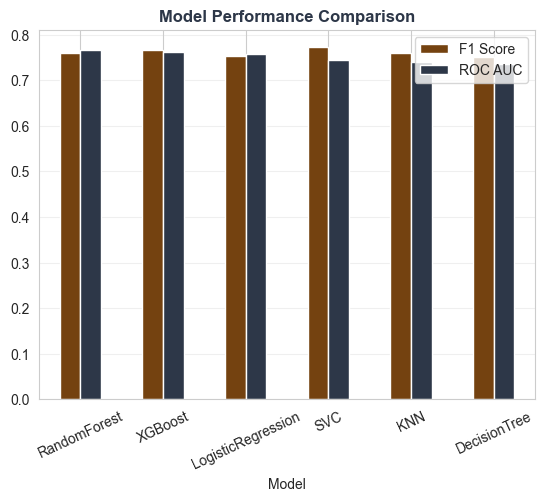

In [65]:
import matplotlib.pyplot as plt

metrics_df = results_df.copy()

plt.figure(figsize=(10,5))

metrics_df.set_index("Model")[["F1 Score", "ROC AUC"]].plot(
    kind="bar",
    color=["#744210", "#2D3748"]
)

plt.title("Model Performance Comparison", color="#2D3748", fontweight="bold")
plt.xticks(rotation=25)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [67]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for name, model in trained_models.items():

    probs = model.predict_proba(X_test)[:,1]

    precision, recall, _ = precision_recall_curve(y_test, probs)

    plt.plot(recall, precision, label=name)

plt.title("Precision-Recall Curve", color="#2D3748", fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

NameError: name 'trained_models' is not defined

<Figure size 800x600 with 0 Axes>

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

for name, model in trained_models.items():

    # -------------------------------
    # SAFE PROBABILITY EXTRACTION
    # -------------------------------
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test)

        # binary classification safety
        if probs.shape[1] == 2:
            probs = probs[:, 1]
        else:
            continue

    elif hasattr(model, "decision_function"):
        probs = model.decision_function(X_test)

        # normalize to [0,1]
        probs = (probs - probs.min()) / (probs.max() - probs.min() + 1e-9)

    else:
        print(f"{name} skipped (no prob method)")
        continue

    fpr, tpr, _ = roc_curve(y_test, probs)

    plt.plot(fpr, tpr, label=name)

# baseline
plt.plot([0,1],[0,1],'--', color="#744210")

plt.title("ROC Curve Comparison", color="#2D3748", fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

NameError: name 'trained_models' is not defined

<Figure size 800x600 with 0 Axes>

In [ ]:
import json

with open('d:/online_retail/src/preprocessingtest.ipynb', 'r', encoding='utf-8') as f:
    nb = json.load(f)

for cell in nb['cells']:
    if 'source' not in cell:
        continue
    
    # Jupyter source can be a string or a list of strings
    if isinstance(cell['source'], list):
        src = ''.join(cell['source'])
    else:
        src = cell['source']

    # 1. Fix the training loop to store best_model
    if 'for model_name, model in models.items():' in src and 'trained_models =' not in src:
        new_src = src.replace('results = []', 'results = []\ntrained_models = {}')
        new_src = new_src.replace('best_model = random_search.best_estimator_', 'best_model = random_search.best_estimator_\n\n    trained_models[model_name] = best_model')
        
        # Write back to cell
        if isinstance(cell['source'], list):
            cell['source'] = new_src.splitlines(True)
        else:
            cell['source'] = new_src

    # 2. Fix the ROC curve plotting logic that uses models.items()
    elif 'for name, model in trained_models.items():' in src and 'roc_curve' in src:
        new_src = src.replace('for name, model in trained_models.items():', 'for name, model in trained_models.items():')
        
        if isinstance(cell['source'], list):
            cell['source'] = new_src.splitlines(True)
        else:
            cell['source'] = new_src

with open('d:/online_retail/src/preprocessingtest.ipynb', 'w', encoding='utf-8') as f:
    json.dump(nb, f, indent=1)

print("Notebook updated successfully.")
